In [1]:
# Cell 1 — imports
%load_ext autoreload
%autoreload 2
import sys
sys.path.append("..") # tells Python to look in the parent folder for your src/ files
import pandas as pd
import matplotlib.pyplot as plt
from src.data_loader import fetch_data, compute_features# Cell 2 — download the data (this hits the internet, takes ~10 seconds)
prices = fetch_data()
print(prices.shape)   # should be roughly (3500, 4) — rows=days, cols=tickers
prices.tail()         # shows the last 5 rows so you can see it worked

/Users/alexanderradovich/Desktop/KAN_regimes/venv/lib/python3.9/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(
[*********************100%***********************]  4 of 4 completed

(3773, 4)


Ticker,GLD,QQQ,SPY,TLT
Date,,,,
2024-12-23,240.960007,520.231567,587.787537,83.175911
2024-12-24,241.440002,527.285767,594.320801,83.527626
2024-12-26,243.070007,526.927612,594.360413,83.480103
2024-12-27,241.399994,519.923096,588.103760,82.795685
2024-12-30,240.630005,513.008240,581.392578,83.461098


In [2]:
# Cell 2 — download the data (this hits the internet, takes ~10 seconds)
prices = fetch_data()
print(prices.shape)   # should be roughly (3500, 4) — rows=days, cols=tickers
prices.tail()         # shows the last 5 rows so you can see it worked

[*********************100%***********************]  4 of 4 completed

(3773, 4)


Ticker,GLD,QQQ,SPY,TLT
Date,,,,
2024-12-23,240.960007,520.231567,587.787537,83.175911
2024-12-24,241.440002,527.285767,594.320801,83.527626
2024-12-26,243.070007,526.927612,594.360413,83.480103
2024-12-27,241.399994,519.923096,588.103760,82.795685
2024-12-30,240.630005,513.008240,581.392578,83.461098


In [3]:
# Cell 3 — compute features
features = compute_features(prices)
print(features.shape)
print(features.columns.tolist()) # lists every feature column you made
features.tail()

(3753, 16)
['GLD_ret', 'GLD_vol', 'GLD_mom', 'GLD_rsi', 'QQQ_ret', 'QQQ_vol', 'QQQ_mom', 'QQQ_rsi', 'SPY_ret', 'SPY_vol', 'SPY_mom', 'SPY_rsi', 'TLT_ret', 'TLT_vol', 'TLT_mom', 'TLT_rsi']


,GLD_ret,GLD_vol,GLD_mom,GLD_rsi,QQQ_ret,QQQ_vol,QQQ_mom,QQQ_rsi,SPY_ret,SPY_vol,SPY_mom,SPY_rsi,TLT_ret,TLT_vol,TLT_mom,TLT_rsi
Date,,,,,,,,,,,,,,,,
2024-12-23,-0.004709,0.010954,-0.035543,44.832751,0.009743,0.011890,0.035436,54.959106,0.005988,0.008463,0.001984,43.503306,-0.009172,0.010203,-0.024837,23.509958
2024-12-24,0.001992,0.008816,-0.004289,44.315676,0.013560,0.012176,0.047819,55.327544,0.011115,0.008789,0.009696,46.499624,0.004229,0.008111,-0.045425,18.594198
2024-12-26,0.006751,0.008942,0.000494,50.685217,-0.000679,0.012173,0.041515,56.130143,0.000067,0.008719,0.004518,47.380430,-0.000569,0.008110,-0.042250,16.843150
2024-12-27,-0.006871,0.009056,-0.008584,47.552400,-0.013293,0.012464,0.035825,48.464154,-0.010527,0.009024,-0.003035,41.368220,-0.008199,0.007925,-0.056638,14.390738
2024-12-30,-0.003190,0.008820,-0.020196,41.458203,-0.013300,0.012790,0.013147,46.730056,-0.011412,0.009232,-0.020497,38.920085,0.008037,0.007739,-0.058772,22.170276


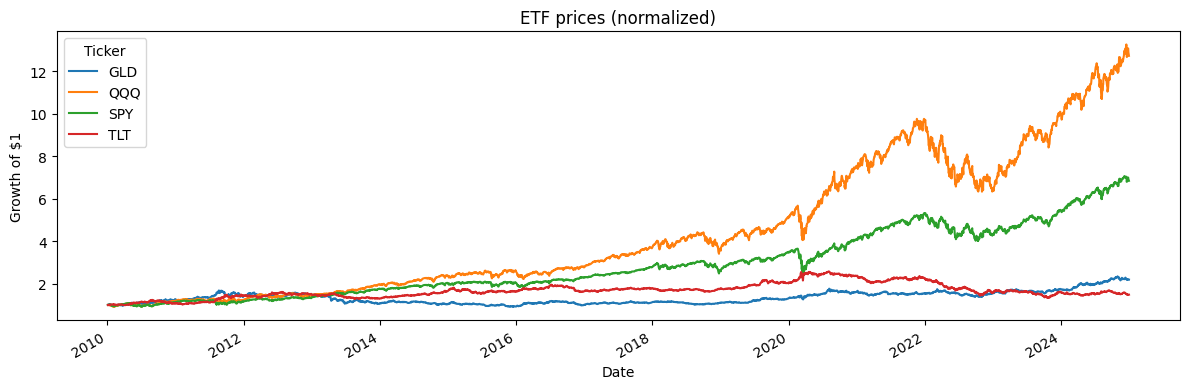

In [4]:
# Cell 4 — plot the ETF prices over time
fig, ax = plt.subplots(figsize=(12, 4))
(prices / prices.iloc[0]).plot(ax=ax) # normalize to 1.0 so all 4 fit on same scale
ax.set_title("ETF prices (normalized)")
ax.set_ylabel("Growth of $1")
plt.tight_layout()
plt.show()

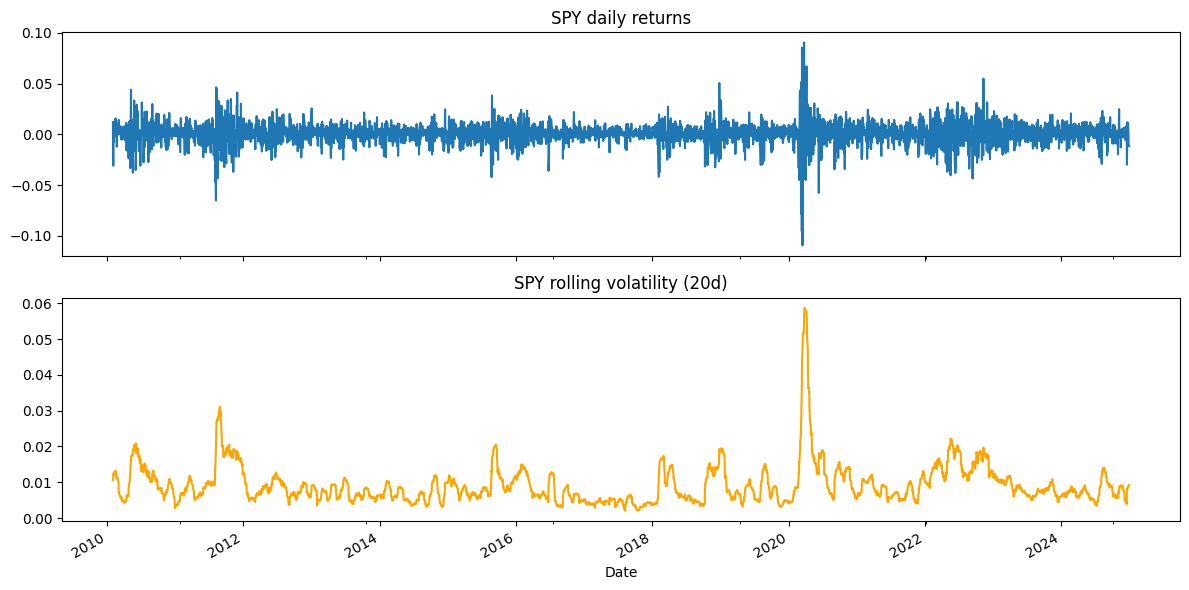

In [5]:
# Cell 5 — plot SPY returns and rolling volatility
fig, axes = plt.subplots(2, 1, figsize=(12, 6), sharex=True)
features["SPY_ret"].plot(ax=axes[0], title="SPY daily returns")
features["SPY_vol"].plot(ax=axes[1], title="SPY rolling volatility (20d)", color="orange")
plt.tight_layout()
plt.show()

In [6]:
import torch
print(torch.__version__)
print(torch.cuda.is_available())  # will almost certainly print False on a Mac, that's fine

2.8.0
False
